<center>
    
# TITANIC SURVIVAL ANALYSIS USING PYTHON(EDA Project) 

</center>

## OBJECTIVE

### Perform data cleaning and exploratory data analysis (EDA) on a dataset of your choice, such as the Titanic

## IMPORTING LIBRARIES 

In [1]:
import pandas as pd
import numpy as np
import random

* pandas ---> used for working with structured data (tables, CSV files)
* numpy ---> used for numerical computations and arrays
* random ---> used to generate random values

## STEP 1: CREATE TITANIC DATASET

In [2]:
np.random.seed(42)

n = 1000

data = []

for i in range(n):
    passenger_id = i + 1
    pclass = random.choice([1, 2, 3])
    sex = random.choice(["male", "female"])
    age = np.random.randint(1, 80)
    sibsp = np.random.randint(0, 5)
    parch = np.random.randint(0, 3)
    fare = np.random.randint(10, 500)
    embarked = random.choice(["S", "C", "Q"])
    
    # Survival rule (for pattern learning)
    if pclass == 1 and sex == "female":
        survived = 1
    elif age < 12:
        survived = 1
    elif pclass == 3 and sex == "male":
        survived = random.choice([0, 0, 1])
    else:
        survived = random.choice([0, 1])
    
    data.append([
        passenger_id, pclass, sex, age,
        sibsp, parch, fare, embarked, survived
    ])

df = pd.DataFrame(data, columns=[
    "PassengerId","Pclass","Sex","Age",
    "SibSp","Parch","Fare","Embarked","Survived"
])

df.to_csv("titanic_1000.csv", index=False)
print("Dataset created successfully!")

Dataset created successfully!


* This code creates a synthetic Titanic dataset with 1000 passengers and saves it as a CSV file.<br>

* It generates random values for features like:<br>
     * Passenger class (Pclass)<br>
     * Sex<br>
     * Age<br>
     * Family size (SibSp, Parch)<br>
     * Fare<br>
     * Embarked location<br>
* Then it applies simple survival rules to assign Survived (0 or 1).<br>
* Finally, the dataset is saved as titanic_1000.csv.

## STEP 2: LOAD DATASET

In [3]:
df = pd.read_csv("titanic_1000.csv")

This line loads the CSV file titanic_1000.csv into a pandas DataFrame called df.

## STEP 3: BASIC DATA CHECK 

In [4]:
df.head(5)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,1,1,male,52,4,2,116,S,0
1,2,3,female,72,4,0,112,C,1
2,3,1,female,75,2,0,109,Q,1
3,4,2,male,24,2,1,318,S,1
4,5,2,female,2,3,1,303,S,1


This command displays the first 5 rows of the dataset stored in df.

In [5]:
df.tail(5)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
995,996,1,female,69,1,1,211,S,1
996,997,1,female,46,4,2,231,C,1
997,998,3,female,3,4,0,244,C,1
998,999,3,female,33,0,2,342,S,0
999,1000,3,female,50,2,2,165,Q,1


This command shows the last 5 rows of the dataset stored in df.

In [6]:
df.columns

Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Survived'],
      dtype='object')

This command shows all the column names present in the DataFrame df.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PassengerId  1000 non-null   int64 
 1   Pclass       1000 non-null   int64 
 2   Sex          1000 non-null   object
 3   Age          1000 non-null   int64 
 4   SibSp        1000 non-null   int64 
 5   Parch        1000 non-null   int64 
 6   Fare         1000 non-null   int64 
 7   Embarked     1000 non-null   object
 8   Survived     1000 non-null   int64 
dtypes: int64(7), object(2)
memory usage: 70.4+ KB


This command provides a summary of the DataFrame structure, including column names, data types, and missing values.

In [8]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2.004000,38.909000,1.933000,0.978000,251.702000,0.621000
std,288.819436,0.810334,22.807387,1.438256,0.803842,141.757308,0.485381
min,1.000000,1.000000,1.000000,0.000000,0.000000,10.000000,0.000000
25%,250.750000,1.000000,19.000000,1.000000,0.000000,132.750000,0.000000
50%,500.500000,2.000000,38.000000,2.000000,1.000000,242.500000,1.000000
75%,750.250000,3.000000,58.250000,3.000000,2.000000,374.500000,1.000000
max,1000.000000,3.000000,79.000000,4.000000,2.000000,498.000000,1.000000


This command generates a statistical summary of all numerical columns in the dataset.

## STEP 4: DATA CLEANING

In [9]:
df.duplicated().sum()

np.int64(0)

Checks how many duplicate rows are present in the dataset.

In [10]:
df.isnull().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Survived       0
dtype: int64

Checks how many missing (null) values are present in each column of the DataFrame.

In [11]:
df.drop_duplicates(inplace=True)

 Removes all duplicate rows from the dataset and updates the same DataFrame (no new copy is created).

## STEP 5: EXPLORATORY DATA ANALYSIS (EDA)

In [12]:
df["Survived"].value_counts()

Survived
1    621
0    379
Name: count, dtype: int64

This command counts the number of occurrences of each value in the Survived column (0 and 1).

### Insights: 
* Shows how many passengers:
   * 0 → Did not survive
   * 1 → Survived
* Helps identify class imbalance in the dataset
* Useful for:
   * Understanding survival distribution 
   * Preparing data for machine learning 
   * Checking if model bias might occur
##### "In short: It tells you the balance between survivors and non-survivors in the dataset."

In [13]:
df["Survived"].mean()

np.float64(0.621)

This command calculates the average value of the Survived column.

### Insights:
* Since Survived is:
    * 1 = Survived
    * 0 = Not survived
* The mean directly represents the survival rate
* Example:
    * If result = 0.38 → 38% passengers survived
* Useful for:
    * Understanding overall outcome 
    * Comparing survival chances across groups (Pclass, Sex, etc.)
    * Feature analysis in ML models 
##### "It gives the percentage of passengers who survived in the dataset."

## STEP 6: VISUALIZATIONS (EDA Core)

###  1. SURVIVAL DISTRIBUTION 

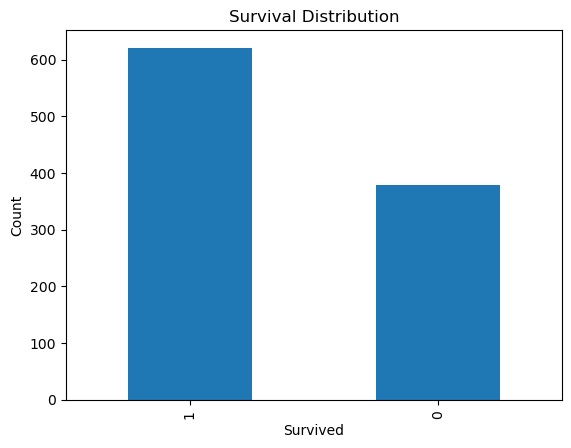

In [14]:
import matplotlib.pyplot as plt

df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

* This code creates a bar chart showing how many passengers survived vs did not survive.
* counts the number of:
    * 0 → Not survived
    * 1 → Survived
* converts these counts into a bar chart.
* Labels improve graph readability

### Insight:
* The chart visually shows the survival distribution of passengers.
* It helps identify class imbalance in the dataset.
* A large difference between 0 and 1 may affect machine learning model performance.
* Visualization makes survival patterns easier to understand and compare.
##### "It gives a clear visual comparison of survivors vs non-survivors in the dataset."

### 2. SURVIVAL BY GENDER

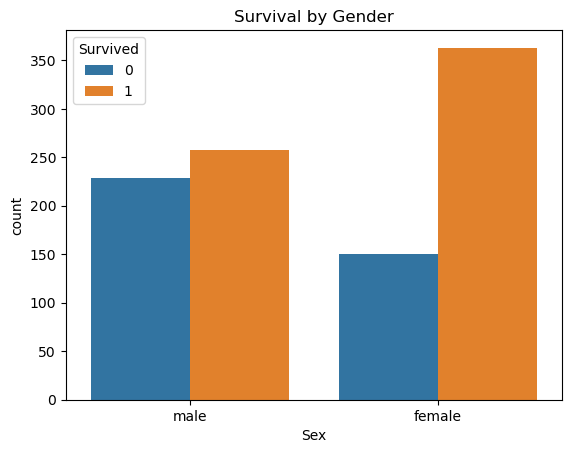

In [15]:
import seaborn as sns

sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

* This code creates a count plot (bar chart) showing how survival varies by gender (Sex).
* sns.countplot() counts compare karta hai
* x="Sex" Male vs Female show karta hai
* hue="Survived" survival categories split karta hai

### Insights:
* Females ---> higher survival rate
* Males ---> lower survival rate
##### "It visually shows how gender affected survival chances in the dataset."

### 3. SURVIVAL BY CLASS

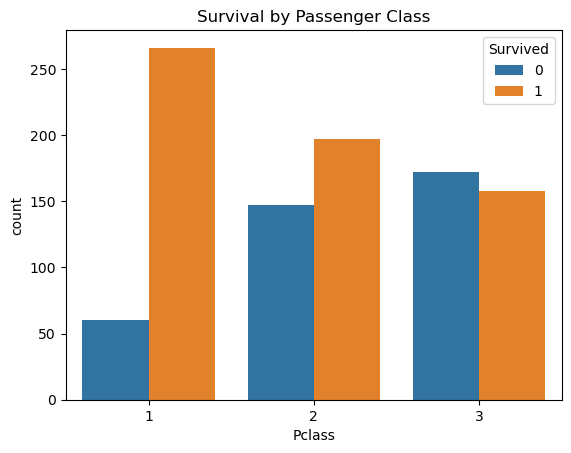

In [16]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

* This code creates a count plot showing survival based on passenger class (Pclass).
* Pclass represents passenger travel class:
    * 1 = First class
    * 2 = Second class
    * 3 = Third class
* hue="Survived" divides each class into:
    * 0 = Not survived
    * 1 = Survived

### Insights:
* The graph helps compare survival rates across passenger classes.
* Higher-class passengers may have had better survival chances.
* It highlights the possible social and economic impact on survival.
##### "It shows how passenger class influenced survival probability in the dataset."

### 4. AGE DISTRIBUTION 

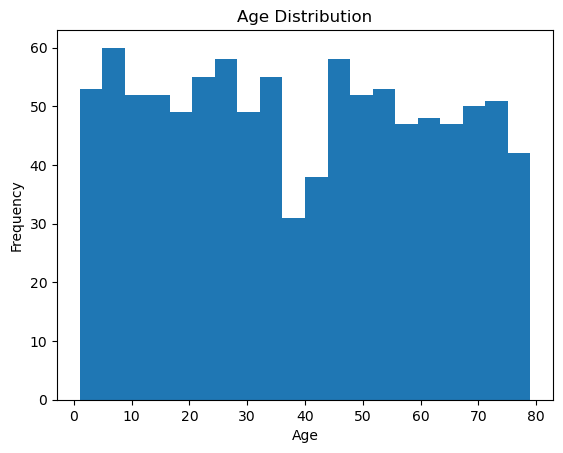

In [17]:
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

* This code creates a histogram showing how ages are distributed in the dataset.
* plt.hist() groups age values into bins (ranges).
* bins=20 divides ages into 20 intervals for better detail.
* Shows:
     * Most common age groups 
     * Spread of passengers’ ages
     * Whether data is skewed or balanced

### Insights:
* Understanding dataset demographics
* Detecting unusual age distribution
* Preparing features for machine learning
##### "It gives a visual breakdown of passenger age distribution in the dataset."

### 5. FARE VS SURVIVAL 

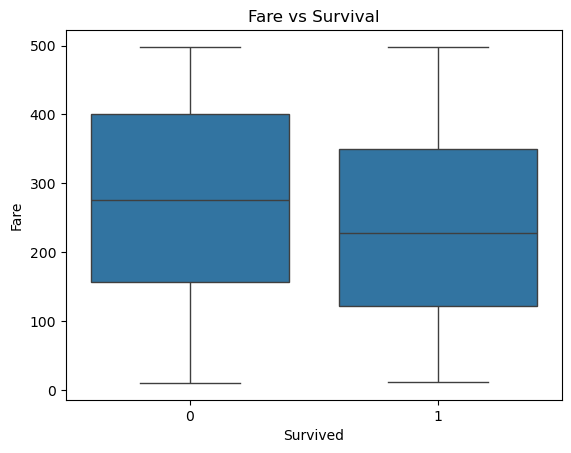

In [18]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Fare vs Survival")
plt.show()

* This code creates a boxplot showing the relationship between Fare and Survival.
* x="Survived" compares two groups:
     * 0 = Not survived
     * 1 = Survived
* y="Fare" represents the ticket price paid by passengers.
* The boxplot shows:
     * Median fare (middle line)
     * Spread of fares (box range)
     * Outliers (dots outside the range)

### Insights:
* Higher fares may be linked with higher survival chances
* First-class passengers often paid more and survived more
* Outliers show passengers with unusually high ticket prices
##### "It helps you understand how ticket fare is related to survival chances in the dataset."

### 6. EMBARKED BY SURVIVAL 

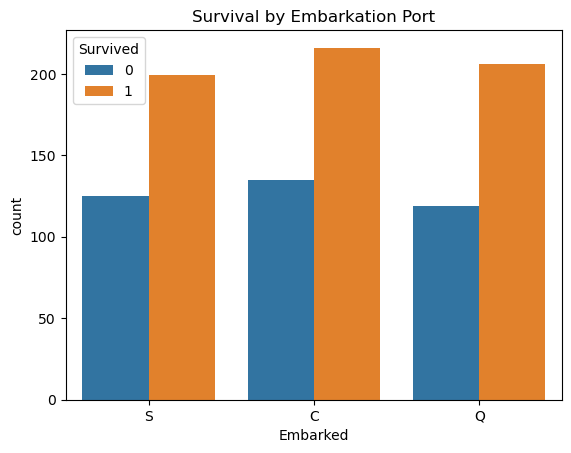

In [19]:
sns.countplot(x="Embarked", hue="Survived", data=df)
plt.title("Survival by Embarkation Port")
plt.show()

* This code creates a count plot showing survival based on embarkation ports.
* Embarked means where passengers boarded the ship:
    * S = Southampton
    * C = Cherbourg
    * Q = Queenstown
* hue="Survived" separates each port into:
    * 0 = Not survived
    * 1 = Survived

### Insights:
* Which port had more passengers
* Survival differences based on boarding location
* Possible link between location, class, and survival
##### "It shows how survival rates vary depending on where passengers boarded the Titanic."

## STEP 7: RELATIONSHIP ANALYSIS (Patterns)

### 1.  GENDER + CLASS vs SURVIVAL 

In [20]:
pd.crosstab([df["Sex"], df["Pclass"]], df["Survived"])

Survived        0    1
Sex    Pclass         
female 1        0  172
       2       75  106
       3       75   85
male   1       60   94
       2       72   91
       3       97   73

* This command creates a cross-tabulation table showing survival counts based on Sex and Passenger Class together.
* Combines two features:
     * Sex (male/female)
     * Pclass (1st, 2nd, 3rd class)
* Compares them against:
     * Survived (0 = Not survived, 1 = Survived)

### Insights:
* Survival patterns for each gender + class combination
* Example patterns you may notice:
     * Female in 1st class ---> highest survival
     * Male in 3rd class ---> lowest survival
* Shows strong interaction between social class and gender
##### "It gives a detailed breakdown of survival rates across both gender and passenger class together."

### 2.  FAMILY SIZE IMPACT

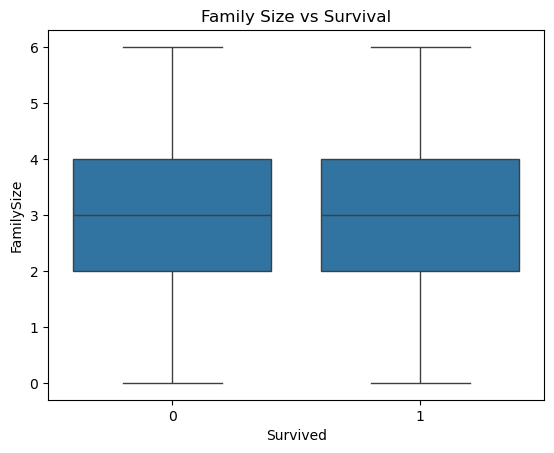

In [21]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

sns.boxplot(x="Survived", y="FamilySize", data=df)
plt.title("Family Size vs Survival")
plt.show()

* This code creates a new feature (FamilySize) and then visualizes how family size affects survival.
* FamilySize = SibSp + Parch
     * SibSp ---> siblings/spouse onboard
     * Parch ---> parents/children onboard
* Then a boxplot compares FamilySize with survival

### Insights:
* Whether passengers with:
    * Small families survived more
    * Large families had lower survival chances
* Helps detect patterns like:
    * Solo travelers vs families
    * Optimal family size for survival likelihood
##### "It helps you understand how traveling alone or with family affected survival chances on the Titanic dataset."

### 3.  CORRELATION HEATMAP

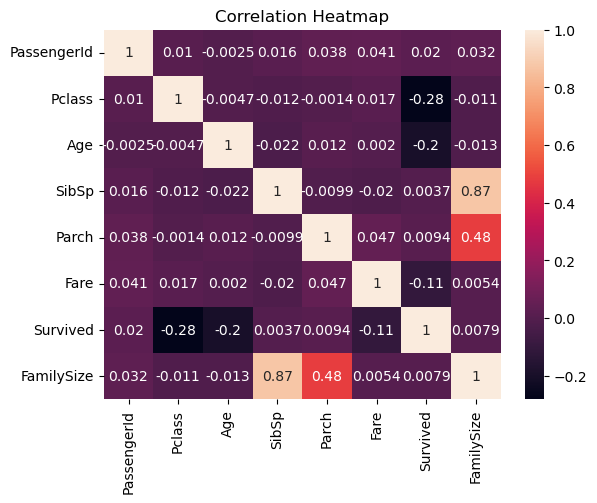

In [22]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

* This code creates a correlation heatmap to show relationships between numerical variables in the dataset.
* Calculates correlation values between numeric columns.
* Correlation ranges:
     * +1 ---> strong positive relationship
     * 0 ---> no relationship
     * -1 ---> strong negative relationship
* Visually displays these relationships as a color grid.
* Shows exact correlation values on the chart.

### Insights:
* Which features are strongly related to Survival
* For example:
     * Pclass may show negative correlation with survival
     * Fare may show positive correlation
* Helps in feature selection for machine learning
##### "It gives a visual map of how strongly different features are connected to each other and to survival."

## STEP 8: SAVE CLEAN DATASET 

In [23]:
df.to_csv("cleaned_titanic_1000.csv", index=False)

This command saves the DataFrame df into a new CSV file named cleaned_titanic_1000.csv.